#Install Dependencies

In [6]:
!pip install -q --upgrade pip
!pip install -q pandas==2.2.2 matplotlib==3.8.0
!pip install -q transformers==4.41.0 spacy==3.8.7 textblob==0.17.1 seaborn==0.13.2
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [matplotlib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [matplotlib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.0 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 115.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spac

#Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
from google.colab import files

 # Load Preprocessed Data

In [2]:
# Load data from Task 1
def load_data():
    uploaded = files.upload()
    filename = next(iter(uploaded))
    df = pd.read_csv(filename)

    # Validate required columns exist
    required_cols = {'review', 'rating', 'date', 'bank'}
    if not required_cols.issubset(df.columns):
        raise ValueError("Missing required columns in input data")

    print(f"Successfully loaded {len(df)} reviews")
    return df

reviews_df = load_data()

Saving bank_reviews_clean.csv to bank_reviews_clean.csv
✅ Successfully loaded 1401 reviews


# Sentiment Analysis Class

In [3]:
# Sentiment analysis module
class SentimentAnalyzer:
    def __init__(self, method='textblob'):
        self.method = method
        if method == 'transformers':
            from transformers import pipeline
            self.model = pipeline("sentiment-analysis")

    def analyze(self, text):
        try:
            if self.method == 'textblob':
                return self._textblob_analysis(text)
            elif self.method == 'transformers':
                return self._transformer_analysis(text)
        except Exception as e:
            print(f"Error analyzing review: {str(e)[:100]}...")
            return ('ERROR', 0.0)

    def _textblob_analysis(self, text):
        analysis = TextBlob(str(text))
        pol = analysis.sentiment.polarity
        return ('POSITIVE' if pol > 0.1 else
                'NEGATIVE' if pol < -0.1 else
                'NEUTRAL', abs(pol))

    def _transformer_analysis(self, text):
        result = self.model(text[:512])[0]  # Truncate to model limit
        return (result['label'].upper(), result['score'])

# Apply Sentiment Analysis

In [4]:
# Apply sentiment analysis to sample
analyzer = SentimentAnalyzer(method='textblob')  # Change to 'transformers' for more accuracy

# Use sample for quick testing (remove .sample() for full analysis)
sample_df = reviews_df.sample(n=500, random_state=42).copy()
sample_df[['sentiment', 'sentiment_score']] = sample_df['review'].apply(
    lambda x: pd.Series(analyzer.analyze(x)))

# Show results
display(sample_df[['review', 'sentiment']].head())

,review,sentiment
1092,I don't have words for your great work.. Reall...,POSITIVE
948,To slow,NEGATIVE
49,the most annoying mobile banking app I've ever...,NEGATIVE
1257,Wow! like his name Super App...,POSITIVE
706,uselss app dont download,NEUTRAL


# Thematic Analysis Setup

In [5]:
# Initialize NLP processor
nlp = spacy.load("en_core_web_sm")

# Define theme keywords
THEME_KEYWORDS = {
    'login_issues': ['login', 'password', 'authenticate'],
    'transactions': ['transfer', 'send', 'payment'],
    'performance': ['slow', 'crash', 'freeze'],
    'ui_ux': ['interface', 'design', 'layout'],
    'customer_service': ['support', 'help', 'response']
}

# Apply Thematic Analysis

In [6]:
def extract_themes(text):
    doc = nlp(text.lower())
    themes = set()
    for token in doc:
        if not token.is_stop and token.is_alpha:
            for theme, keywords in THEME_KEYWORDS.items():
                if token.lemma_ in keywords:
                    themes.add(theme)
    return list(themes) if themes else ['other']

sample_df['themes'] = sample_df['review'].apply(extract_themes)

# Visualization 1 - Sentiment by Bank

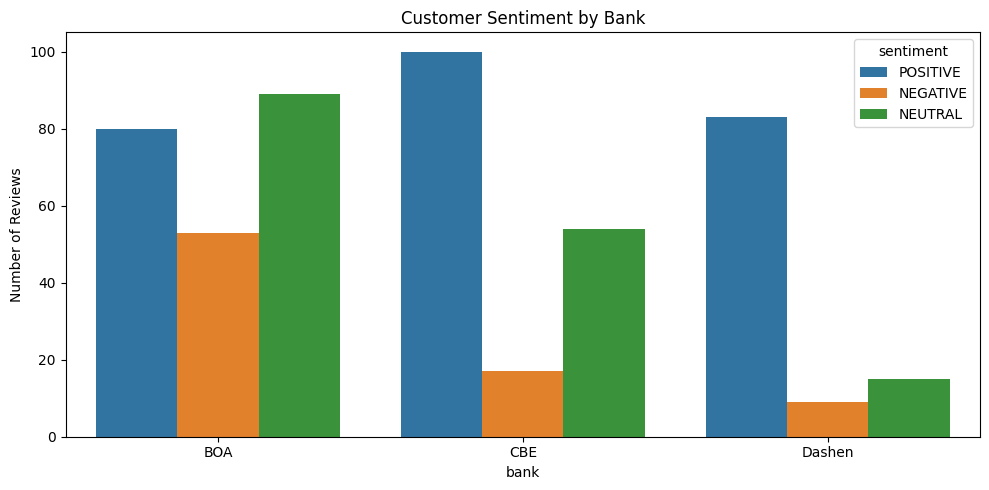

In [7]:
# Sentiment distribution plot
plt.figure(figsize=(10, 5))
sns.countplot(data=sample_df, x='bank', hue='sentiment')
plt.title("Customer Sentiment by Bank")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# Visualization 2 - Common Themes

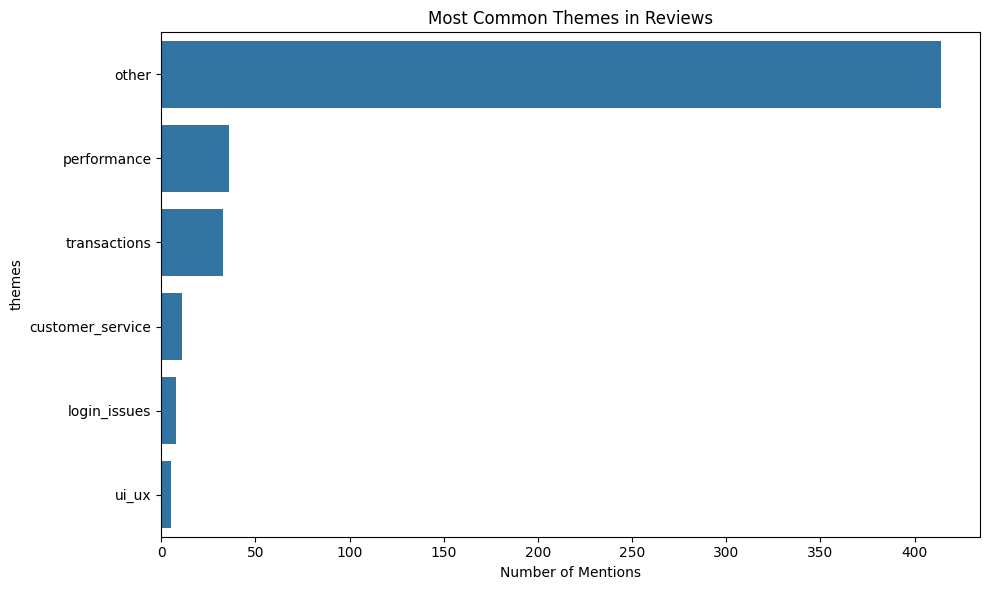

In [8]:
# Theme frequency plot
themes_expanded = sample_df.explode('themes')
plt.figure(figsize=(10, 6))
sns.countplot(data=themes_expanded, y='themes',
             order=themes_expanded['themes'].value_counts().index)
plt.title("Most Common Themes in Reviews")
plt.xlabel("Number of Mentions")
plt.tight_layout()
plt.show()

# Save Results

In [9]:
# Prepare and download results
output_df = sample_df[['bank', 'review', 'rating', 'date',
                      'sentiment', 'sentiment_score', 'themes']]
output_df.to_csv('analyzed_reviews.csv', index=False)
files.download('analyzed_reviews.csv')

print("✅ Analysis complete! File downloaded as 'analyzed_reviews.csv'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Analysis complete! File downloaded as 'analyzed_reviews.csv'


In [10]:
# In Colab's last cell:
from google.colab import files
import shutil

# Create zip of Task 2 files
!mkdir -p task-2/{analysis,outputs/plots}
!cp sentiment.py task-2/analysis/
!cp analyzed_reviews.csv task-2/outputs/
!mv *.png task-2/outputs/plots/
shutil.make_archive('task-2', 'zip', 'task-2')
files.download('task-2.zip')

cp: cannot stat 'sentiment.py': No such file or directory
mv: cannot stat '*.png': No such file or directory


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# In Colab's last cell:
from google.colab import files
files.download('main_analysis.py')
files.download('outputs/analyzed_reviews.csv')
!zip -r plots.zip outputs/plots/
files.download('plots.zip')

FileNotFoundError: Cannot find file: main_analysis.py